In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

In [4]:
@njit(cache=True)
def parametric_unfilt_sho_expects_numba(del_t, period_number, eta, k, gamma, x0, p0):
    w_real = 50000 * 2*np.pi  #rad/s
    m_bead = 4.8e-18 #kg
    hbar = 1.054e-34 #Js
    
    w_scale = w_real
    m_scale = m_bead
    x_scale = np.sqrt(hbar/(m_scale*w_scale))
    p_scale = np.sqrt(hbar*m_scale*w_scale)
    t_scale = 1/w_scale
    
    w = w_real/w_scale
    m = m_bead/m_scale
    
    T = (2*np.pi)/w
    t = period_number*T
    steps = int(t/del_t)
    

    t_arr = np.empty(steps)
    t_per_arr = np.empty(steps)
    exp_x = np.empty(steps)
    exp_p = np.empty(steps)
    var_x_arr = np.empty(steps)
    var_p_arr = np.empty(steps)
    cov_xp_arr = np.empty(steps)
    exp_x_sq = np.empty(steps)
    exp_p_sq = np.empty(steps)
    alpha_x_stream = np.empty(steps)
    alpha_p_stream = np.empty(steps)

    #intial conditions
    x = x0
    p = p0
    alpha_x = x 
    alpha_p = 0.0
    var_x = 1/(2*m*w)
    var_p = m*w/2
    cov_xp = 0.0
    x_sq = var_x + x**2
    p_sq = var_p + p**2
    
    epsilon = -2*gamma/w
    w_sq = w**2*(1-2*epsilon)
    phi = np.arctan2(p, x)
    phi_p = np.pi/2 - 2*phi
    x_rot = x
    p_rot = p
    phi_rot = np.arctan2(p_rot,x_rot)
    phi_p_rot = np.pi/2 - 2*phi_rot

    exp_x[0] = x
    exp_p[0] = p
    var_x_arr[0] = var_x
    var_p_arr[0] = var_p 
    cov_xp_arr[0]= cov_xp

    exp_x_sq[0] = x_sq
    exp_p_sq[0] = p_sq
    t_arr[0] = 0.0
    t_per_arr[0] = 0.0
    
    alpha_x_stream[0] = alpha_x
    alpha_p_stream[0] = alpha_p

    for i in range(steps - 1):

        del_W = np.random.normal(0.0, np.sqrt(del_t))

        x += (1/m*p*del_t) + (np.sqrt(8*eta*k)*var_x*del_W) 
        p += (-m* w_sq*x*del_t) + (np.sqrt(8*eta*k)*cov_xp*del_W) 
        
        var_x += ((2/m*cov_xp) - (8*eta*k*var_x**2)) * del_t
        var_p += ((-2*m*w_sq*cov_xp) + 2*k - (8*eta*k*cov_xp**2)) * del_t
        cov_xp += (1/m*var_p - m*w_sq*var_x - (8*eta*k*var_x*cov_xp)) *del_t
        
        x_sq = var_x + x**2
        p_sq = var_p + p**2

        alpha_x = x + (del_W/(np.sqrt(8*eta*k*del_t)))
        alpha_x_stream[i+1] = alpha_x

        if i >= 1:
            alpha_p = m*(alpha_x_stream[i+1] - alpha_x_stream[i])/del_t
        else:
            alpha_p = 0.0
        alpha_p_stream[i+1] = alpha_p


        x_rot = x*np.cos(w*t_arr[i+1]) - p*np.sin(w*t_arr[i+1])
        p_rot = x*np.sin(w*t_arr[i+1]) + p*np.cos(w*t_arr[i+1])

        
        phi_rot = np.arctan2(p_rot, x_rot)
        phi_p_rot = np.pi/2 - 2*phi_rot

        w_sq = w**2*(1 - 2*epsilon*np.cos(2*w*t_arr[i+1] + phi_p_rot))
        
        t_now = (i+1) * del_t
        t_arr[i+1] = t_now
        t_per_arr[i+1] = t_now/T
        exp_x[i+1] = x
        exp_p[i+1] = p
        var_x_arr[i+1] = var_x
        var_p_arr[i+1] = var_p
        cov_xp_arr[i+1] = cov_xp
        exp_x_sq[i+1] = x_sq
        exp_p_sq[i+1] = p_sq
        

    t_real_arr = t_arr *t_scale
    exp_x_real  = exp_x * x_scale
    exp_p_real  = exp_p * p_scale
    var_x_real = var_x_arr * x_scale**2
    var_p_real = var_p_arr * p_scale**2
    cov_xp_real = cov_xp_arr * x_scale*p_scale
    exp_x_sq_real = exp_x_sq * x_scale**2
    exp_p_sq_real = exp_p_sq * p_scale**2

    
    
    alpha_x_stream_real = alpha_x_stream * x_scale
    alpha_p_stream_real = alpha_p_stream * p_scale
    
    
    return (t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real, exp_x_sq_real,exp_p_sq_real)

In [5]:
t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real = parametric_unfilt_sho_expects_numba(del_t=0.001,period_number=10000, eta=1, k=0.05, gamma=0.01, x0=20, p0=20)

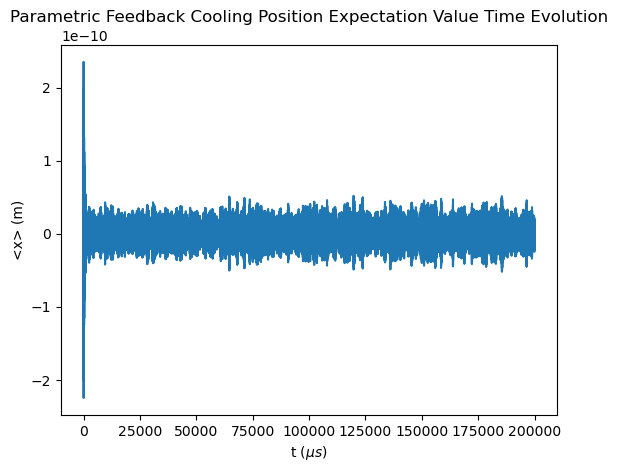

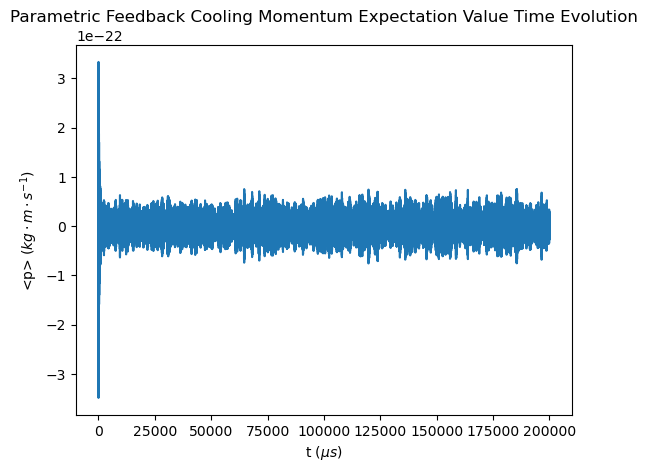

In [6]:
plt.figure()
plt.plot(t_real_arr*10**6, exp_x_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<x> (m)")
plt.title("Parametric Feedback Cooling Position Expectation Value Time Evolution")
plt.show()

plt.figure()
plt.plot(t_real_arr*10**6, exp_p_real)
plt.xlabel("t ($\mu s$)")
plt.ylabel("<p> ($kg \cdot m \cdot s^{-1}$)")
plt.title("Parametric Feedback Cooling Momentum Expectation Value Time Evolution")
plt.show()

In [7]:
def t_eff(p_sq, x_sq, m, w):
    kB = 1.3806*10**-23
    
    T_eff = (p_sq/m + m*w**2*x_sq)/(2*kB)
    return T_eff
    

In [12]:
gamma_list = np.logspace(-3, 0.5, num=6)
gamma_list_real = gamma_list* 50000
w_real = 50000 * 2*np.pi  #rad/s
m_bead = 4.8e-18 #kg
T_list = []

In [13]:
gamma_list

array([1.00000000e-03, 5.01187234e-03, 2.51188643e-02, 1.25892541e-01,
       6.30957344e-01, 3.16227766e+00])

In [14]:
for gamma in gamma_list:
    t_real_arr, t_per_arr,exp_x_real,exp_p_real, alpha_x_stream_real, alpha_p_stream_real, var_x_real, var_p_real, cov_xp_real,exp_x_sq_real,exp_p_sq_real = parametric_unfilt_sho_expects_numba(del_t=0.01,period_number=10000, eta=1, k=0.05, gamma=gamma, x0=20, p0=20)
    x_sq_real = np.mean(exp_x_sq_real[-1570796:])
    p_sq_real = np.mean(exp_p_sq_real[-1570796:])

    t_e = t_eff(p_sq_real, x_sq_real, m=m_bead, w=w_real)
    T_list.append(t_e)
    
    

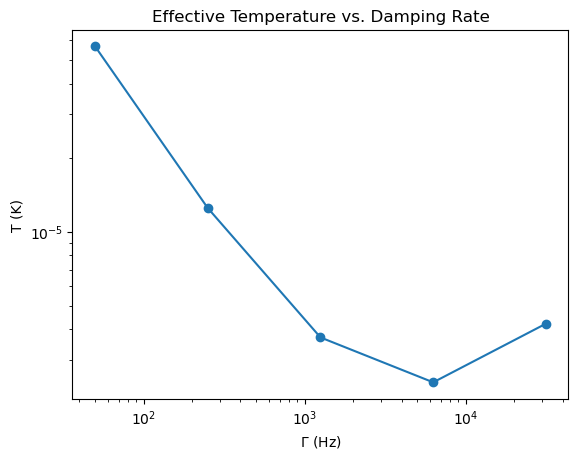

In [16]:
plt.figure()
plt.scatter(gamma_list_real, np.array(T_list))
plt.plot(gamma_list_real, np.array(T_list))
plt.xlabel(r"$\Gamma$ (Hz)")
plt.ylabel("T (K)")
plt.title("Effective Temperature vs. Damping Rate")
plt.loglog()
plt.show()